<a href="https://colab.research.google.com/github/hemanthch517-lab/ML/blob/main/expepl3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Accuracy: 0.8044692737430168

Confusion Matrix:
[[98 12]
 [23 46]]


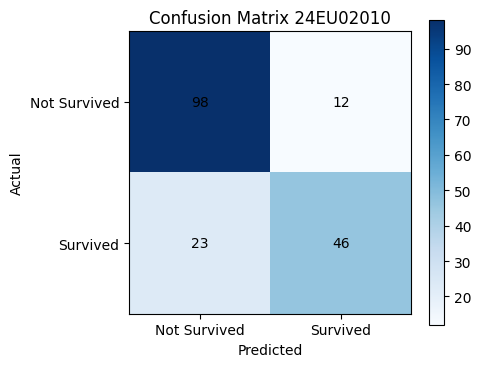


Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



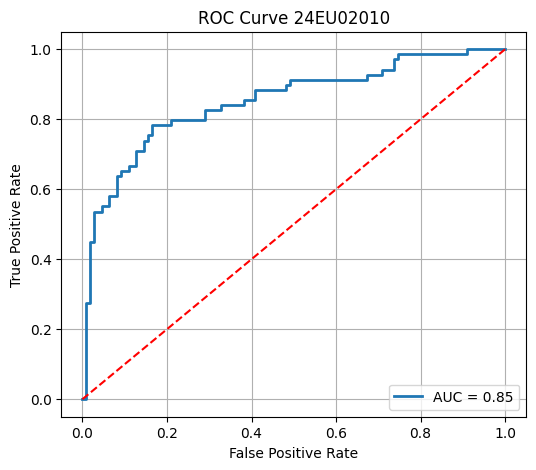

Cross Validation Scores: [0.7877095  0.78651685 0.78089888 0.76966292 0.82022472]
Mean Cross Validation Accuracy: 0.7890025735986442


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# Load Titanic dataset
titanic = sns.load_dataset("titanic")

# Display first 5 rows
print("First 5 Rows:\n")
print(titanic.head())

# Select required columns and create an independent copy
data = titanic[[
    "survived",
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]].copy()

# Fill missing values
data["age"] = data["age"].fillna(data["age"].median())
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])

# Encode categorical variables
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

data["sex"] = le_sex.fit_transform(data["sex"])
data["embarked"] = le_embarked.fit_transform(data["embarked"])

# Features and Target
X = data.drop(columns=["survived"])
y = data["survived"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("\nAccuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix 24EU02010")
plt.colorbar()

plt.xticks([0,1], ["Not Survived","Survived"])
plt.yticks([0,1], ["Not Survived","Survived"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ROC Curve
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label="AUC = {:.2f}".format(roc_auc))
plt.plot([0,1], [0,1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve 24EU02010")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Cross Validation
scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Mean Cross Validation Accuracy:", scores.mean())